# Figure 5 panel C - peptide-binding-groove enrichment

In [1]:
import os

import pandas as pd
from scipy.stats import fisher_exact

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='white')

In [2]:
# --- Manuscript plotting style ---
axis_label_font_size = 7
tick_label_font_size = 6
plt.rcParams.update({
    'font.size': axis_label_font_size,
    'axes.titlesize': axis_label_font_size,
    'axes.labelsize': axis_label_font_size,
    'xtick.labelsize': tick_label_font_size,
    'ytick.labelsize': tick_label_font_size,
    'legend.fontsize': tick_label_font_size,
    'legend.title_fontsize': axis_label_font_size,
})

# --- Input paths ---
INTERMEDIATE_DIR = 'intermediate_data/'
COX_RES_DIR = os.path.join(INTERMEDIATE_DIR, 'panel_b_positional_cox_results')

# --- Output path (this notebook's only write target) ---
FIGURE_DIR = 'figures/'
os.makedirs(FIGURE_DIR, exist_ok=True)

# --- Analysis configuration (must match the data-generation notebook) ---
EXP_NAME = 'first_immuno_lot_only_no_bmi'
TOX_TYPE = 'adrenal_insufficiency'
GRADES = [0, 2, 3]  # 0 = Grade 1+, 2 = Grade 2+, 3 = Grade 3+

# Peptide-binding groove positions on the DRB1 ARD (used by the enrichment test).
GROOVE_POSITIONS = {9, 11, 13, 26, 28, 30, 37, 47, 57, 60, 61, 67, 70, 71,
                    74, 77, 78, 81, 82, 85, 86, 89}
ARD_START, ARD_END = 6, 94


(5.90625, 0.012999022842482255)

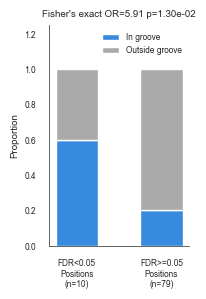

In [3]:
def plot_groove_enrichment(cox_res_dir=COX_RES_DIR, figure_dir=FIGURE_DIR):
    """Test whether FDR-significant positions (grade 1+, i.e.
    grade_thresh == 0) are enriched in the peptide-binding groove, and plot
    the result"""
    all_res = []
    for ae_grade in GRADES:
        path = os.path.join(cox_res_dir, f"{EXP_NAME}_{TOX_TYPE}_grade{ae_grade}_positional_cox_res.csv")
        if os.path.exists(path):
            all_res.append(pd.read_csv(path))
    res_all_grades = pd.concat(all_res, axis=0)

    informative_positions = set(
        res_all_grades[(res_all_grades.grade_thresh == 0) & (res_all_grades.fdr <= 0.05)].ungapped_position
    )

    ard = set(range(ARD_START, ARD_END + 1))
    groove = GROOVE_POSITIONS & ard
    non_hits = ard - informative_positions

    hits_in = len(informative_positions & groove)
    hits_out = len(informative_positions) - hits_in
    nonhits_in = len(non_hits & groove)
    nonhits_out = len(non_hits) - nonhits_in

    or_, pval = fisher_exact([[hits_in, hits_out], [nonhits_in, nonhits_out]], alternative="greater")

    n_hits = len(informative_positions)
    n_nonhits = len(non_hits)

    fig, ax = plt.subplots(figsize=(2, 3))
    sns.despine()
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    ax.bar([0, 1], [hits_in/n_hits, nonhits_in/n_nonhits], 0.5, label="In groove", color="#378ADD")
    ax.bar([0, 1], [hits_out/n_hits, nonhits_out/n_nonhits], 0.5,
           bottom=[hits_in/n_hits, nonhits_in/n_nonhits], label="Outside groove", color="#AAAAAA")

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"FDR<0.05\nPositions\n(n={n_hits})", f"FDR>=0.05\nPositions\n(n={n_nonhits})"])
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1.25)
    ax.set_title(f"Fisher's exact OR={or_:.2f} p={pval:.2e}")
    ax.legend(loc="upper right", frameon=False)
    plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, "panel_c_ai_informative_pos_enrichment.pdf"), dpi=300, bbox_inches="tight")

    return or_, pval


plot_groove_enrichment()
